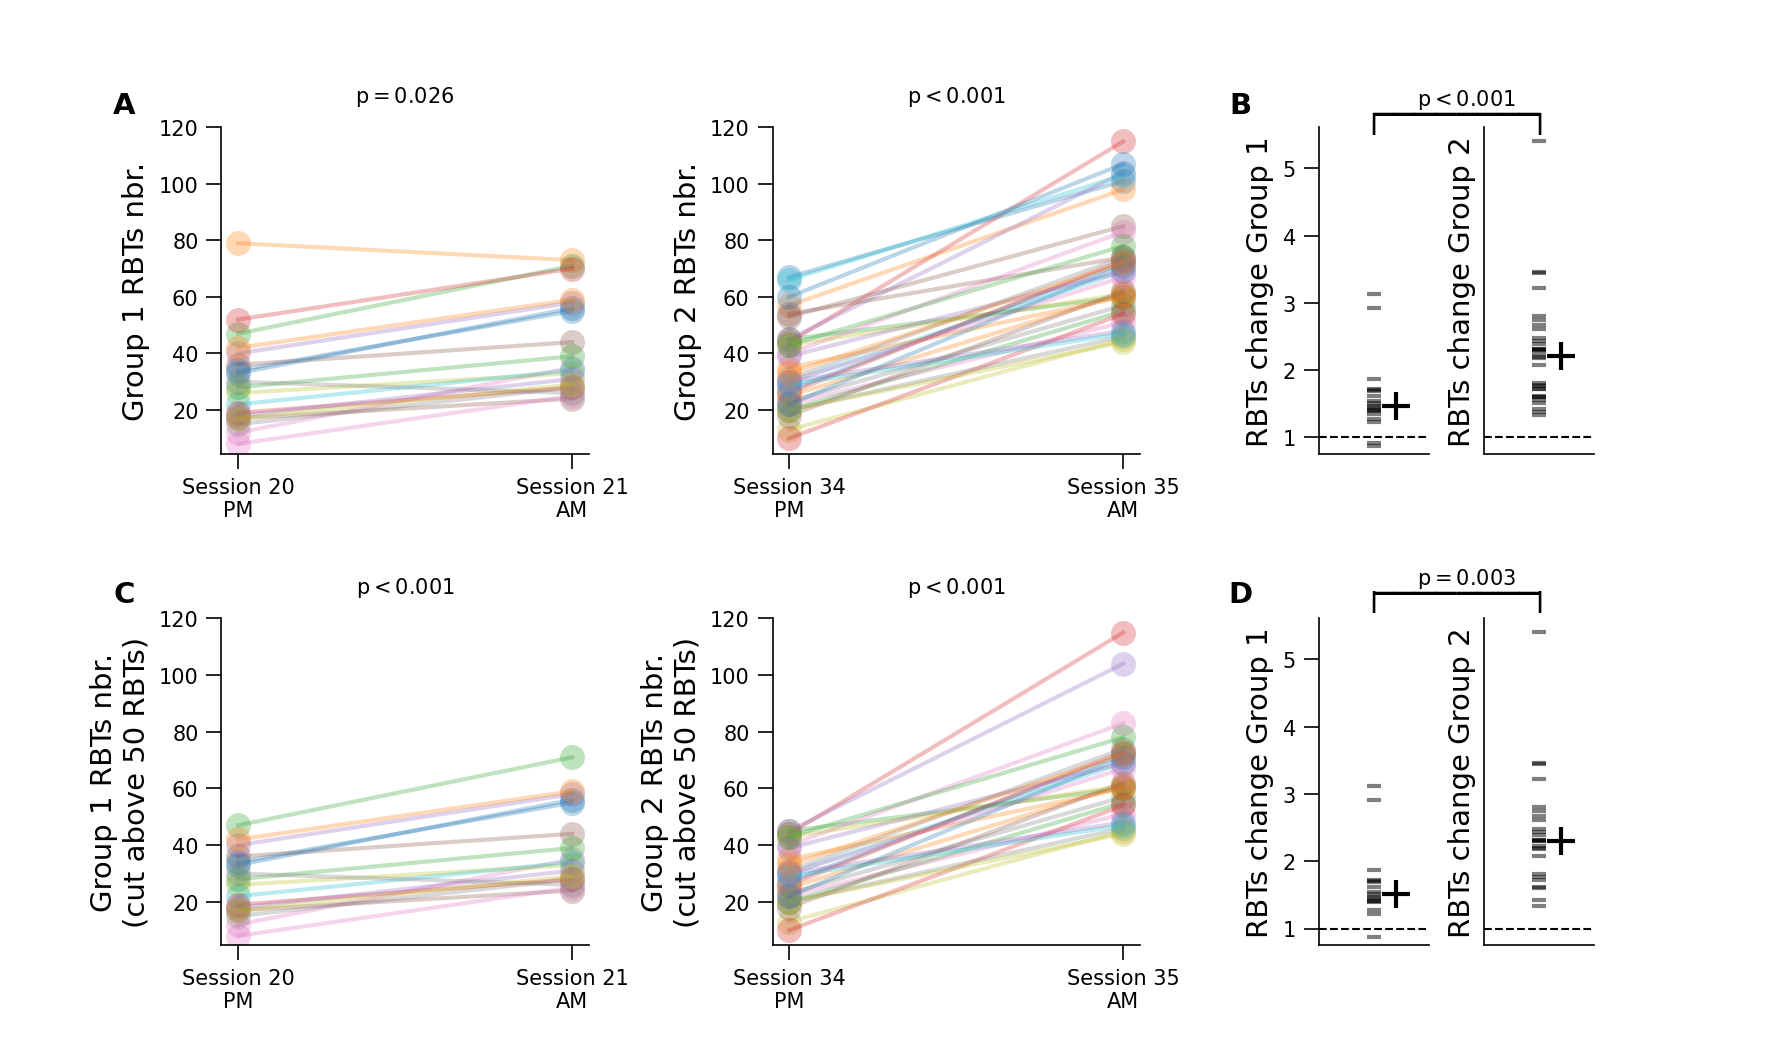

In [14]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("FigureS19.png")
display(img)


# 1. Importing necessary libraries and general functions  

In [2]:
import os
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import numpy as np
import pickle
import similaritymeasures as sm
from scipy.stats import permutation_test
from scipy.stats import spearmanr

plt.style.use('paper.mplstyle')



In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

path_to_data_folder_1='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data/'
path_to_data_folder_2='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group2Data/'

# path_to_data_folder_1='/home/david/MyLocalData/4TowersTask_MethodPaper/Group1Data'
# path_to_data_folder_2='/home/david/MyLocalData/4TowersTask_MethodPaper/Group2Data'

# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/AurelienData/'

# Analysing the entire group of mice
mice_to_analyse_1 = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]

mice_to_analyse_2 = ['MOU3974','MOU3975', 'MOU3987', 'MOU3988', 'MOU3991', 'MOU3992', 'MOU4551', 'MOU4552', 'MOU4560', 'MOU4561', 'MOU4562',
                   'MOU4563', 'MOU4623', 'MOU4964', 'MOU4965', 'MOU4986', 'MOU4987', 'MOU4988', 'MOU4993', 'MOU5007', 'MOU5008','MOU5130',
                   'MOU5131', 'MOU5136', 'MOU5140', 'MOU5142', 'MOU5143', 'MOU5144', 'MOU5145', 'MOU5148', 'MOU5149', 'MOU5158']


# Verify that all folders in mice_to_analyse_1 and mice_to_analyse_2 are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse_1 if not os.path.isdir(os.path.join(path_to_data_folder_1, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders from group 1 are present in data folder.")

missing_folders = [mouse for mouse in mice_to_analyse_2 if not os.path.isdir(os.path.join(path_to_data_folder_2, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders from group 2 are present in data folder.")


# Print the number of mice, the list of mice
print(f'{len(mice_to_analyse_1)+len(mice_to_analyse_2)} {"mice" if len(mice_to_analyse_1)+len(mice_to_analyse_2) > 1 else "mouse"} will be analysed.')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes_1 = [18,26]
first_and_last_session_indexes_2 = [32,40]

# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set. TODO: Should reformulate this 
session_index_offset_1 = first_and_last_session_indexes_1[0]
session_index_offset_2 = first_and_last_session_indexes_2[0]

# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

All mice folders from group 1 are present in data folder.
All mice folders from group 2 are present in data folder.
51 mice will be analysed.


# 3. Chosing illustration mice and sessions  

In [5]:
# Chose the 2 mice that are highlighted in statistics across figures
illustration_mice_1 = ['MOUEml1_8', 'MOUEml1_5']
illustration_mice_2 = ['MOU3974', 'MOU4561']

# Set the limits of the x-axis on the statistics plots
xlim_stats_1 = [0.5,8.5] #[first_and_last_session_indexes_1[0]+0.5,first_and_last_session_indexes_1[1]+0.5]
xlim_stats_2 = [0.5,8.5] #[first_and_last_session_indexes_2[0]+0.5,first_and_last_session_indexes_2[1]+0.5]


# 4. General functions

In [6]:
def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54



In [7]:

def statistic(sample_1, sample_2, axis):

    """
    Compute the difference of the average of two samples of values.

    sample_1 (numpy.ndarray): first sample
    sample_2 (numpy.ndarray): second sample
    axis (int): axis along which to compute the medians
    """

    return np.nanmedian(sample_1, axis=axis) - np.nanmedian(sample_2, axis=axis)


def plot_two_sessions_metric(metric_persession, sessions_to_compare_indexes, mice_to_analyse, ax, first_session_index=0, interval_to_include = (-np.inf, np.inf), alternative='two-sided', mice_to_highlight=[], ylabel=None, xlim=None, ylim=None):

    """
    Plot the input metric for all mice, two sessions. All comparisons are overlaid in one plot,
    and a permutation test is performed on the first vs second session data, with the p-value shown in the title.
    
    Arguments:
        mouse_value_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        mice_to analyse (list): List of mice from mouse_values_persession to use
        ax (matplotlib.axes.Axes): ax object in which to plot
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
        interval_to_include (list): Interval in which included values will be shown in the plot and included in statistics
        mice_to_highlight (list, optional): List of mice's name whose corresponding line will be highlighted on the plot
        last_n_sessions (int, optional): Number of last sessions to average
        ylabel (sting, optional): Name of y label
        xlim (tuple, optional): display limit on x axis
        ylim (tuple, optional): display limit on y axis
    """
    
    # Create lists to contain the values of each mouse in first and n last sessions 
    first_session_metrics = []
    second_session_metrics = []

    # Iterate on each mouse
    for mouse in mice_to_analyse:

        # Selecting sessions under the limit
        values_persession = metric_persession[mouse]
        
        if len(values_persession) == 0:
            print(f"No data available for mouse {mouse}. Skipping.")
            continue
        
        # Extract the values from the data
        metric_list = [d[1] for d in values_persession]

        
        # Get the first session's values in the interval, else use numpy.nan
        if interval_to_include[0]<metric_list[sessions_to_compare_indexes[0]]<interval_to_include[1]:

            first_session_metric = metric_list[sessions_to_compare_indexes[0]]
            second_session_metric = metric_list[sessions_to_compare_indexes[1]]
        
        else:

            first_session_metric = np.nan
            second_session_metric = np.nan
        
        # Store the values for statistical testing
        first_session_metrics.append(first_session_metric)
        second_session_metrics.append(second_session_metric)
        
        # Plot the comparison for the current mouse with a line connecting the two points
        if not(mouse in mice_to_highlight):
        
            ax.plot([1, 2], [first_session_metric, second_session_metric], marker='o',  markeredgewidth=0.0, alpha=0.3)
    
        elif mouse == mice_to_highlight[0]: # Highlight mouse if its name is in illustration_mice 

            ax.plot([1, 2], [first_session_metric, second_session_metric], color='darkorange', marker='o', markeredgewidth=0.0, alpha=1, zorder=100, label=f"Mouse {mice_to_highlight.index(mouse)+1}")

        elif mouse == mice_to_highlight[1]: # Highlight mouse if its name is in illustration_mice 

            ax.plot([1, 2], [first_session_metric, second_session_metric], color='green', marker='o', markeredgewidth=0.0, alpha=1, zorder=100, label=f"Mouse {mice_to_highlight.index(mouse)+1}")
        
    # Perform the permutation test on paired values 
    if len(first_session_metrics) > 0:
        res = permutation_test((first_session_metrics, second_session_metrics), statistic, alternative=alternative, n_resamples=1000, permutation_type = 'samples')
          
    # Set the ticks
    ax.set_xticks([1, 2], [f'Session {sessions_to_compare_indexes[0] + first_session_index+1}\nPM', f'Session {sessions_to_compare_indexes[1]+ first_session_index+1}\nAM'], fontsize=5)
    
    # Set ylabel
    ax.set_ylabel(ylabel)
    # Set x and y axis limit
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    # Plot the result of the permutation p-value as title

    # pvalue_to_print = rf'Permutation p$ = {np.round(p_value,3)}$' if p_value>=0.01 else 'Permutation p$<0.01$'
    pvalue_to_print = rf'p$ = {np.round(res.pvalue,3)}$' if res.pvalue>=0.01 else rf'p$<0.001$'
    
    ax.set_title(pvalue_to_print, fontsize=5)


In [8]:
def plot_ratio_scatter(ax, mouse_metric_persession, sessions_to_compare_indexes, mice_to_analyse, first_session_index = 0, interval_to_include = (-np.inf, np.inf), xlabel=None, ylabel=None):

    ratios_list = []

    # Iterate on each mouse
    for mouse in mice_to_analyse:

        # Selecting sessions under the limit
        metric_persession = mouse_metric_persession[mouse]
        
        if len(metric_persession) == 0:
            print(f"No data available for mouse {mouse}. Skipping.")
            continue
        
        # Extract the metric's values from the data
        values_list = [d[1] for d in metric_persession]
        
        # Get the first session's time ratio if in the interval, else use numpy.nan
        if interval_to_include[0]<values_list[sessions_to_compare_indexes[0]]<interval_to_include[1]:

            first_session_metric = values_list[sessions_to_compare_indexes[0]]
            second_session_metric = values_list[sessions_to_compare_indexes[1]]
        
        else:

            first_session_metric = np.nan
            second_session_metric = np.nan
        
        # Store the values for statistical testing
        ratios_list.append(second_session_metric/first_session_metric)

    ax.scatter(np.zeros(len(ratios_list)), ratios_list, s=10, marker='_', alpha=0.5, color='k')

    ax.set_xlabel(xlabel)

    if not ylabel:

        ylabel = f'Sessions {sessions_to_compare_indexes[1] + first_session_index+1}/{sessions_to_compare_indexes[0] + first_session_index+1}'
    
    ax.set_ylabel(ylabel)
    
    ax.set_xticks([])
    
    return ratios_list



# 5. Computations

In [9]:
# Initialize dictionaries to store the various metrics for each mouse
mouse_total_runs_persession_1 = {mouse: [] for mouse in mice_to_analyse_1}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse_1:

    folder_path_mouse_to_process = os.path.join(path_to_data_folder_1, mouse)
    
    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])
    
    sessions_to_process = sessions_to_process[first_and_last_session_indexes_1[0]:first_and_last_session_indexes_1[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Process each session for the current mouse
    for session_index,session_to_process in enumerate(sessions_to_process):

        # Determine the rewarded direction for all sessions of the current mouse
        session_traj_df, session_runs_df, session_param_df = load_data(folder_path_mouse_to_process,session_to_process)

        # Define the pickle file path
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)
        
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exists for session {session_to_process}, skipping .....')
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run between towers results from the session data
        runs_between_towers = session_data['all_epochs']['run_between_towers']

        # Compute the total number of runs between towers
        total_runs = len(runs_between_towers)        
        
        # Initialize lists to store runs speeds
        runs_max_speed = []
        runs_distance = []
       
        # Append session data to the respective dictionaries
        mouse_total_runs_persession_1[mouse].append([session_index+1,total_runs])


Mouse MOUEml1_5. There is/are 8 sessions:
['MOUEml1_5_20230430-1021', 'MOUEml1_5_20230430-1529', 'MOUEml1_5_20230501-1038', 'MOUEml1_5_20230501-1601', 'MOUEml1_5_20230502-1133', 'MOUEml1_5_20230502-1645', 'MOUEml1_5_20230503-1032', 'MOUEml1_5_20230503-1722'] 

Mouse MOUEml1_8. There is/are 8 sessions:
['MOUEml1_8_20230430-1116', 'MOUEml1_8_20230430-1621', 'MOUEml1_8_20230501-1129', 'MOUEml1_8_20230501-1651', 'MOUEml1_8_20230502-1227', 'MOUEml1_8_20230502-1740', 'MOUEml1_8_20230503-1125', 'MOUEml1_8_20230503-1812'] 

Mouse MOUEml1_11. There is/are 8 sessions:
['MOUEml1_11_20230430-1213', 'MOUEml1_11_20230430-1724', 'MOUEml1_11_20230501-1223', 'MOUEml1_11_20230501-1753', 'MOUEml1_11_20230502-1326', 'MOUEml1_11_20230502-1842', 'MOUEml1_11_20230503-1228', 'MOUEml1_11_20230503-1909'] 

Mouse MOUEml1_12. There is/are 8 sessions:
['MOUEml1_12_20230430-1228', 'MOUEml1_12_20230430-1738', 'MOUEml1_12_20230501-1238', 'MOUEml1_12_20230501-1808', 'MOUEml1_12_20230502-1340', 'MOUEml1_12_20230502-185

In [10]:
# Initialize dictionaries to store the various metrics for each mouse
mouse_total_runs_persession_2 = {mouse: [] for mouse in mice_to_analyse_2}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse_2:

    folder_path_mouse_to_process = os.path.join(path_to_data_folder_2, mouse)
    
    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])
    
    sessions_to_process = sessions_to_process[first_and_last_session_indexes_2[0]:first_and_last_session_indexes_2[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')

    # Process each session for the current mouse
    for session_index,session_to_process in enumerate(sessions_to_process):

        # Determine the rewarded direction for all sessions of the current mouse
        session_traj_df, session_runs_df, session_param_df=load_data(folder_path_mouse_to_process,session_to_process)

        # Define the pickle file path
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)
        
        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exists for session {session_to_process}, skipping .....')
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run between towers results from the session data
        runs_between_towers = session_data['all_epochs']['run_between_towers']

        # Compute the total number of runs between towers
        total_runs = len(runs_between_towers)        
        
        # Append session data to the respective dictionaries
        mouse_total_runs_persession_2[mouse].append([session_index+1,total_runs])


Mouse MOU3974. There is/are 8 sessions:
['MOU3974_20230321-1140', 'MOU3974_20230321-1711', 'MOU3974_20230325-1314', 'MOU3974_20230325-1715', 'MOU3974_20230326-1338', 'MOU3974_20230326-1744', 'MOU3974_20230327-1219', 'MOU3974_20230327-1724'] 

Mouse MOU3975. There is/are 8 sessions:
['MOU3975_20230321-1153', 'MOU3975_20230321-1725', 'MOU3975_20230325-1327', 'MOU3975_20230325-1729', 'MOU3975_20230326-1353', 'MOU3975_20230326-1759', 'MOU3975_20230327-1234', 'MOU3975_20230327-1739'] 

Mouse MOU3987. There is/are 8 sessions:
['MOU3987_20230321-1109', 'MOU3987_20230321-1640', 'MOU3987_20230325-1245', 'MOU3987_20230325-1644', 'MOU3987_20230326-1309', 'MOU3987_20230326-1714', 'MOU3987_20230327-1143', 'MOU3987_20230327-1655'] 

Mouse MOU3988. There is/are 8 sessions:
['MOU3988_20230321-1123', 'MOU3988_20230321-1654', 'MOU3988_20230325-1258', 'MOU3988_20230325-1658', 'MOU3988_20230326-1323', 'MOU3988_20230326-1728', 'MOU3988_20230327-1156', 'MOU3988_20230327-1709'] 

Mouse MOU3991. There is/are 

In [11]:

def plot_metric_vs_ratio_scatter(ax, mouse_metric_persession, sessions_to_compare_indexes, mice_to_analyse, text_loc, first_session_index = 0, xlabel=None, ylabel=None, title=None):

    ratios_list = []

    first_session_values_list = []
    
    # Iterate on each mouse
    for mouse in mice_to_analyse:

        # Selecting sessions under the limit
        metric_persession = mouse_metric_persession[mouse]
        
        if len(metric_persession) == 0:
            print(f"No data available for mouse {mouse}. Skipping.")
            continue
        
        # Extract the metric's values from the data
        values_list = [d[1] for d in metric_persession]
        
        # Get the first session's values
        first_session_value = values_list[sessions_to_compare_indexes[0]]
        first_session_values_list.append(first_session_value)

        # Get the second session's values
        second_session_value = values_list[sessions_to_compare_indexes[1]]
        
        # Store the values for statistical testing
        ratios_list.append(second_session_value/first_session_value)

    res = spearmanr(first_session_values_list, ratios_list)
    rho = res.statistic
    # pvalue = res.pvalue
        
    ax.scatter(first_session_values_list, ratios_list, s=10, marker='+', alpha=0.5, color='k')

    # text_to_plot = rf'$\rho = {round(rho,2)}$' + '\n' + rf'p$={round(pvalue,2)}$' if pvalue>0.001 else rf'$\rho = {round(rho,2)}$' + '\n' + rf'p$<0.001$'
    text_to_plot = rf'$\rho = {round(rho,2)}$'
    
    ax.text(text_loc[0],text_loc[1],text_to_plot, fontsize=5)

    ax.set_xlabel(xlabel)

    if not ylabel:

        ylabel = f'Ratio sessions {sessions_to_compare_indexes[1] + first_session_index+1}/{sessions_to_compare_indexes[0] + first_session_index+1}'
    
    ax.set_ylabel(ylabel)
    
    ax.set_title(title)
    ax.legend(frameon=False)
    # ax.set_xticks([])




# 7. Whole figure

/tmp/ipykernel_13939/2768762373.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


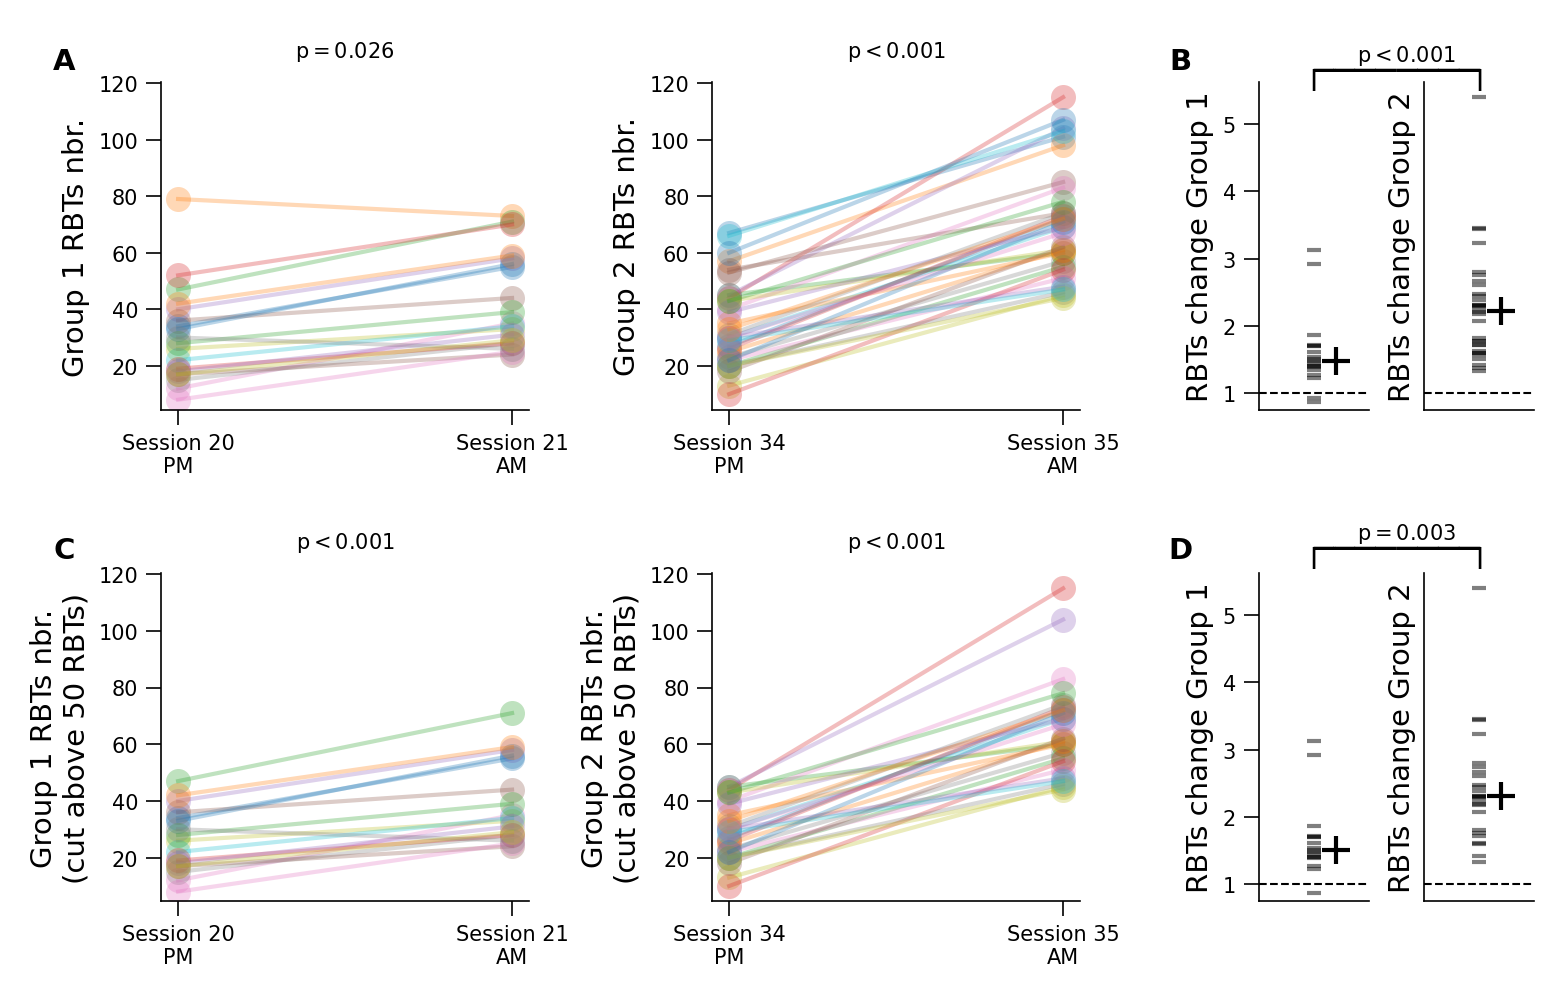

In [12]:
fig=plt.figure(figsize=(cm2inch(15), cm2inch(9)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(2, 2 , wspace=0.3, hspace=0.5, width_ratios=(1,0.3))

sessions_to_compare = (1,2)

### Panel A ###
cell1 = gs[0,0].subgridspec(1, 2, wspace=0.5)
ax11 = plt.subplot(cell1[0])
ax12 = plt.subplot(cell1[1])

plot_two_sessions_metric(mouse_total_runs_persession_1, sessions_to_compare, mice_to_analyse_1, ax11, 
                            alternative='less', first_session_index=first_and_last_session_indexes_1[0], mice_to_highlight=[], ylabel=f'Group 1 RBTs nbr.', xlim=None, ylim=None)
plot_two_sessions_metric(mouse_total_runs_persession_2, sessions_to_compare, mice_to_analyse_2, ax12, 
                            alternative='less', first_session_index=first_and_last_session_indexes_2[0], mice_to_highlight=[], ylabel=f'Group 2 RBTs nbr.', xlim=None, ylim=None)

ylim_1 = ax11.get_ylim()
ylim_2 = ax12.get_ylim()

ylim = (min(ylim_1[0],ylim_2[0]), max(ylim_1[1],ylim_2[1]))

ax11.set_ylim(ylim)
ax12.set_ylim(ylim)

fig.text(0.07, 0.9, 'A', weight='bold', va='center', ha='center', fontsize=7)

### Panel B ###
cell2 = gs[0,1].subgridspec(1, 2, wspace=0.5)
ax21 = plt.subplot(cell2[0])
ax22 = plt.subplot(cell2[1])

ylim_1 = 'RBTs change Group 1'
ylim_2 = 'RBTs change Group 2'

ratios_list_1 = plot_ratio_scatter(ax21, mouse_total_runs_persession_1, sessions_to_compare, mice_to_analyse_1, 
                                   first_session_index=first_and_last_session_indexes_1[0], ylabel=ylim_1)
ratios_list_2 = plot_ratio_scatter(ax22, mouse_total_runs_persession_2, sessions_to_compare, mice_to_analyse_2, 
                                   first_session_index=first_and_last_session_indexes_2[0], ylabel=ylim_2)
    

res = permutation_test((ratios_list_1,ratios_list_2), statistic, alternative='less', n_resamples=1000, permutation_type='independent')
pvalue_to_print = rf'p$ = {np.round(res.pvalue,3)}$' if res.pvalue>=0.001 else r'p$<0.001$'
fig.text(0.8,0.9, pvalue_to_print, fontsize=5)
    
ax21.scatter(0.4, np.nanmedian(ratios_list_1), color='k', alpha= 1, marker='+', s=45)
ax22.scatter(0.4, np.nanmedian(ratios_list_2), color='k', alpha= 1, marker='+', s=45)
ax21.set_xlim(-1,1)
ax22.set_xlim(-1,1)

ax21.axhline(1, color='k', linestyle = '--', lw=0.5)
ax22.axhline(1, color='k', linestyle = '--', lw=0.5)

ylim_1 = ax21.get_ylim()
ylim_2 = ax22.get_ylim()

ylim = (min(ylim_1[0],ylim_2[0]), max(ylim_1[1],ylim_2[1]))

ax22.set_yticks(())

ax21.set_ylim(ylim)
ax22.set_ylim(ylim)

fig.text(0.7, 0.9, 'B', weight='bold', va='center', ha='center', fontsize=7)

### Panel C ###
cell3 = gs[1,0].subgridspec(1, 2, wspace=0.5)

ax31 = plt.subplot(cell3[0])
ax32 = plt.subplot(cell3[1])

plot_two_sessions_metric(mouse_total_runs_persession_1, sessions_to_compare, mice_to_analyse_1, ax31, 
                            alternative='less', first_session_index=first_and_last_session_indexes_1[0], interval_to_include=(0,50), mice_to_highlight=[], ylabel=f'Group 1 RBTs nbr.\n(cut above 50 RBTs)', xlim=None, ylim=None)
plot_two_sessions_metric(mouse_total_runs_persession_2, sessions_to_compare, mice_to_analyse_2, ax32, 
                            alternative='less', first_session_index=first_and_last_session_indexes_2[0], interval_to_include=(0,50), mice_to_highlight=[], ylabel=f'Group 2 RBTs nbr.\n(cut above 50 RBTs)', xlim=None, ylim=None)

ylim_1 = ax31.get_ylim()
ylim_2 = ax32.get_ylim()

ylim = (min(ylim_1[0],ylim_2[0]), max(ylim_1[1],ylim_2[1]))

ax31.set_ylim(ylim)
ax32.set_ylim(ylim)

fig.text(0.775, 0.9,'________')
fig.text(0.773, 0.873,'l', fontsize=7)
fig.text(0.8665, 0.873,'l', fontsize=7)

fig.text(0.07, 0.44, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Panel D ###
cell4 = gs[1,1].subgridspec(1, 2, wspace=0.5)
ax41 = plt.subplot(cell4[0])
ax42 = plt.subplot(cell4[1])

ylim_1 = 'RBTs change Group 1'
ylim_2 = 'RBTs change Group 2'

ratios_list_1 = plot_ratio_scatter(ax41, mouse_total_runs_persession_1, sessions_to_compare, mice_to_analyse_1, 
                                   first_session_index=first_and_last_session_indexes_1[0], interval_to_include=(0,50), ylabel=ylim_1)
ratios_list_2 = plot_ratio_scatter(ax42, mouse_total_runs_persession_2, sessions_to_compare, mice_to_analyse_2, 
                                   first_session_index=first_and_last_session_indexes_2[0], interval_to_include=(0,50), ylabel=ylim_2)

res = permutation_test((ratios_list_1,ratios_list_2), statistic, alternative='less', n_resamples=1000, permutation_type='independent')
pvalue_to_print = rf'p$ = {np.round(res.pvalue,3)}$' if res.pvalue>=0.001 else r'p$<0.001$'
fig.text(0.8,0.45, pvalue_to_print, fontsize=5)

ax41.scatter(0.4, np.nanmedian(ratios_list_1), color='k', alpha= 1, marker='+', s=45)
ax42.scatter(0.4, np.nanmedian(ratios_list_2), color='k', alpha= 1, marker='+', s=45)
ax41.set_xlim(-1,1)
ax42.set_xlim(-1,1)

ax41.axhline(1, color='k', linestyle = '--', lw=0.5)
ax42.axhline(1, color='k', linestyle = '--', lw=0.5)

ylim_1 = ax21.get_ylim()
ylim_2 = ax22.get_ylim()

ylim = (min(ylim_1[0],ylim_2[0]), max(ylim_1[1],ylim_2[1]))

ax42.set_yticks(())

ax41.set_ylim(ylim)
ax42.set_ylim(ylim)

fig.text(0.775, 0.45,'________')
fig.text(0.773, 0.423,'l', fontsize=7)
fig.text(0.8665, 0.423,'l', fontsize=7)
fig.text(0.7, 0.44, 'D', weight='bold', va='center', ha='center', fontsize=7)

fig.tight_layout()
plt.savefig("FigureS19.png", facecolor='w', edgecolor='none', format="png", dpi=300)


In [13]:
# Save the figure as a PDF
fig.savefig("FigureS19.pdf", format="pdf", bbox_inches='tight', dpi=300)
